# TP 1 : Statistique inférentielle

In [1]:
 #0.
set.seed(123)
N=sample(200:400,1)
N


[1] 358

## 1. L'espérance de $X$
On considère une loi uniforme discrète sur $\{1, \dots, N\}$. L'espérance est donnée par :

$$
\begin{aligned}
E(X) &= \sum_{k=1}^{N} k \cdot P(X=k) \\
&= \sum_{k=1}^{N} k \cdot \frac{1}{N} \\
&= \frac{1}{N} \sum_{k=1}^{N} k \\
&= \frac{1}{N} \cdot \frac{N(N+1)}{2} \\
E(X) &= \frac{N+1}{2}
\end{aligned}
$$

---

## 2. Construction de l'estimateur $\hat{N}_1$
On sait que $E(\bar{X}_n) = E(X)$. On cherche un estimateur $\hat{N}_1$ tel que $E(\hat{N}_1) = N$ (estimateur sans biais).

D'après la **loi forte des grands nombres** :
$$\bar{X}_n \longrightarrow \frac{N+1}{2}$$

En isolant $N$, on obtient l'estimateur :
$$\hat{N}_1 = 2\bar{X}_n - 1 \longrightarrow N$$

---

## 3. Risque quadratique $R(\hat{N}_1)$
Le risque quadratique est défini par $R(\hat{N}_1) = E\left[ (\hat{N}_1 - N)^2 \right]$. Comme l'estimateur est sans biais ($E(\hat{N}_1) = N$), le risque est égal à la variance :

$$
\begin{aligned}
R(\hat{N}_1) &= Var(\hat{N}_1) \\
&= Var(2\bar{X}_n - 1) \\
&= Var(2\bar{X}_n) \\
&= 4 Var(\bar{X}_n) \\
&= 4 \frac{Var(X)}{n}
\end{aligned}
$$

### Calcul de $Var(X)$
$$
\begin{aligned}
Var(X) &= E(X^2) - (E(X))^2 \\
&= \frac{(N+1)(2N+1)}{6} - \left( \frac{N+1}{2} \right)^2 \\
&= \frac{N^2 - 1}{12}
\end{aligned}
$$

### Résultat final
En remplaçant $Var(X)$ dans l'expression du risque :
$$
R(\hat{N}_1) = 4 \cdot \frac{N^2 - 1}{12n} = \mathbf{\frac{N^2 - 1}{3n}}
$$

## 2. Estimateur de Maximum de Vraisemblance (EMV)

### 2.1. Calcul de la fonction de vraisemblance
La fonction de vraisemblance $L$ pour un échantillon $(x_1, \dots, x_n)$ de loi uniforme sur $\{1, \dots, N\}$ est :

$$
\begin{aligned}
L(x_1, \dots, x_n | N) &= P(X_1=x_1, X_2=x_2, \dots, X_n=x_n | N) \\
&= \prod_{i=1}^{n} P(X_i = x_i | N) \\
&= \prod_{i=1}^{n} \frac{1}{N} \mathbb{1}_{\{x_i \le N\}} \\
&= \left( \frac{1}{N} \right)^n \mathbb{1}_{\{\max(x_i) \le N\}}
\end{aligned}
$$

### 2.2. Détermination de l'estimateur $\hat{N}_2$
Pour maximiser $L(N)$, il faut choisir le plus petit $N$ possible tel que la condition $N \ge \max(x_i)$ soit respectée. On en déduit :
$$\hat{N}_2 = \max_{1 \le i \le n} (X_i)$$

---

## 3. Étude d'un troisième estimateur $\hat{N}_3$

On définit l'estimateur corrigé $\hat{N}_3$ pour limiter le biais de la valeur maximale :
$$\hat{N}_3 = \left( 1 + \frac{1}{n} \right) \hat{N}_2 - 1$$

### Calcul de l'espérance $E(\hat{N}_3)$
En utilisant la propriété de linéarité de l'espérance :
$$
\begin{aligned}
E(\hat{N}_3) &= E\left[ \left( 1 + \frac{1}{n} \right) \hat{N}_2 - 1 \right] \\
&= \left( 1 + \frac{1}{n} \right) E(\hat{N}_2) - 1
\end{aligned}
$$

*(Note : D'après les calculs du TP, avec $E(\hat{N}_2) = N - \frac{N-n}{n+1}$, on montre que cet estimateur tend à corriger le biais du maximum).*

---

## Calcul détaillé de $Var(X)$
Le calcul de la variance pour une loi uniforme discrète $X \sim \mathcal{U}(\{1, \dots, N\})$ est :

$$
\begin{aligned}
Var(X) &= E(X^2) - (E(X))^2 \\
E(X^2) &= \frac{1}{N} \sum_{k=1}^{N} k^2 = \frac{(N+1)(2N+1)}{6} \\
E(X) &= \frac{N+1}{2}
\end{aligned}
$$

Développement du calcul :
$$
\begin{aligned}
Var(X) &= \frac{(N+1)(2N+1)}{6} - \left( \frac{N+1}{2} \right)^2 \\
&= \frac{2(N+1)(2N+1) - 3(N+1)^2}{12} \\
&= \frac{(N+1) \left[ 2(2N+1) - 3(N+1) \right]}{12} \\
&= \frac{(N+1) [4N + 2 - 3N - 3]}{12} \\
&= \frac{(N+1)(N-1)}{12} \\
Var(X) &= \frac{N^2 - 1}{12}
\end{aligned}
$$

In [2]:
#4.
n=5
D=5000

help(sample)
mat_ech=matrix(sample.int(N,n*D,replace=TRUE),D,n)
mat_ech

179,216,63,127,229
14,141,70,334,100
195,143,24,229,138
306,162,206,288,48
118,143,76,113,219
299,180,82,68,281
229,148,290,21,50
244,148,245,132,140
14,278,276,198,353
153,315,319,298,292
90,224,167,325,160


In [3]:
#5
N1=function(obs) {2*mean(obs)-1}
N2=function(obs){max(obs)}
N3=function(obs){(1+1/n)*max(obs)-1}


h1=apply(mat_ech,MARGIN = 1,FUN = N1)
h2=apply(mat_ech,MARGIN = 1,FUN = N2)
h3=apply(mat_ech,MARGIN = 1,FUN = N3)

In [4]:
#6
summary(h1)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   57.8   294.2   357.0   357.6   419.8   641.0 

In [5]:
summary(h2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   58.0   272.0   312.0   299.3   339.0   358.0 

In [6]:
summary(h3)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   68.6   325.4   373.4   358.1   405.8   428.6 

Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
“"add" is not a graphical parameter”


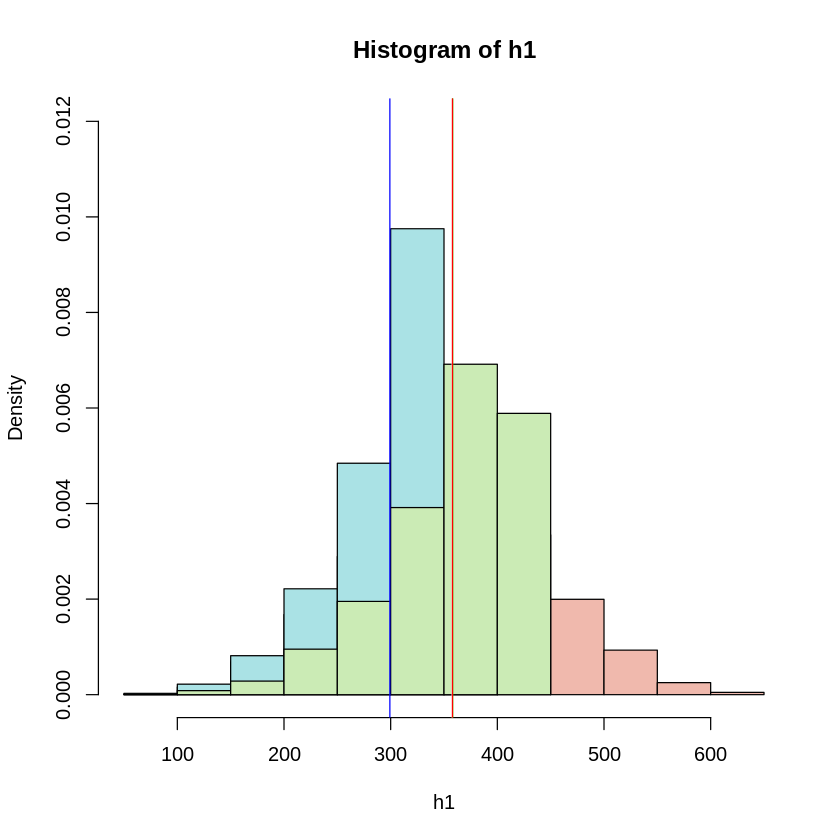

In [17]:
#7
hist(h1,breaks = 10,col="#F0B9AD",probability = TRUE,ylim = c(0,0.012))
hist(h2,add=TRUE,breaks = 10,col="#AAE2E5",probability = TRUE,ylim = c(0,0.012))
hist(h3,add=TRUE,breaks = 10,col="#CBEBB5",probability = TRUE,ylim = c(0,0.012))

abline(v=mean(h1),col="Pink")#Pink
abline(v=mean(h2),col="Blue")#Blue
abline(v=mean(h3),col="Green")#green
abline(v =N,add=TRUE,col="red")



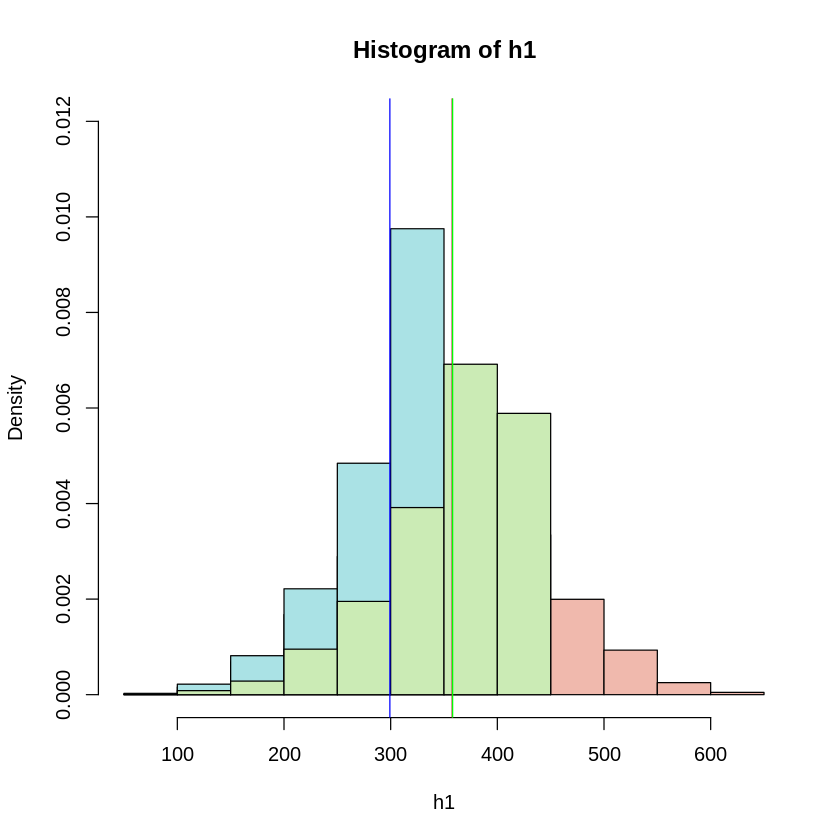

In [27]:
hist(h1,breaks = 10,col="#F0B9AD",probability = TRUE,ylim = c(0,0.012))
hist(h2,add=TRUE,breaks = 10,col="#AAE2E5",probability = TRUE,ylim = c(0,0.012))
hist(h3,add=TRUE,breaks = 10,col="#CBEBB5",probability = TRUE,ylim = c(0,0.012))
# abline(v =N,add=TRUE,col="red")
abline(v=mean(h1),col="Brown")#Brown
abline(v=mean(h2),col="Blue")#Blue
abline(v=mean(h3),col="Green")#green


### Que constatez vous ?
---

- En analysant les résumés statistiques et les écarts-types de chaque estimateurs, nous remarquons plusieurs choses fondamentales concernant la qualité de nos estimateurs :

    - L'estimateur $\hat{N}_1$ (en marron sous le vert) : Sa moyenne est très proche de la vraie valeur de $N$ (en rouge) (il est bien sans biais, comme démontré à la question 1). En revanche, son écart-type (sa variance) est extrêmement élevé. L'estimation s'étale énormément, ce qui le rend peu fiable sur un seul échantillon de 5 chars capturés.

  - L'estimateur $\hat{N}_2$ (en bleu) : Il a une variance très faible (les valeurs sont resserrées), mais il est fortement biaisé. Sa moyenne est très en dessous de la vraie valeur $N$. C'est logique : le numéro de série maximum observé ne peut jamais dépasser la production totale, il la sous-estime donc systématiquement.

  - L'estimateur $\hat{N}_3$ (en vert) : Il représente le meilleur compromis. En appliquant le facteur de correction à $\hat{N}_2$, sa moyenne se recale parfaitement sur la vraie valeur $N$ (il est sans biais). De plus, son écart-type reste très inférieur à celui de $\hat{N}_1$. C'est un estimateur nettement plus performant.